# **Student Data Analysis**


---


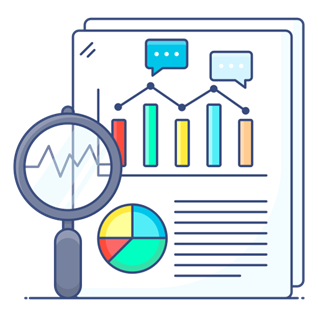

**For the given student_data.txt file do the following:**

1. Read data from **student_data.txt** file:

    Each line in the file contains a student's name followed by their marks.

2. Save data in a dictionary:

    Key: Student name
    Value: List of marks

3. Perform the following calculations without using built-in functions (e.g., sum(), max(), min(), avg(), sort()):

    > Use math functions like pow() and sqrt() where necessary.
    
    > Organize the code into functions.
    
    > Use exception handling to manage errors.


4. Calculate and store the following information in an output dictionary:

    4.1-  Maximum average with student name
    
    4.2- Maximum mark with student name
    
    4.3-  Minimum average with student name
    
    4.4-  Minimum mark with student name
    
    4.5-  Standard deviation
    
    4.6-  First quartile (Q1)
    
    4.7-  Second quartile (Median or Q2)
    
    4.8-  Third quartile (Q3)
    
    4.9-  Interquartile Range (IQR)
    
    4.10-  Most frequent mark

5. Export the output dictionary to a JSON file.

In [1]:
import numpy as np
import math

filepath = 'C:/Users/yarah/Projects/LeadingPoint/student_data.txt'

students = {}

with open(filepath, encoding="utf-8-sig") as f:
    for line in f:
        parts = [part.strip() for part in line.split(",")]
        name = parts[0]
        score = [int(s) for s in parts[1:]]
        students[name] = score

print(students)
print(len(students))

{'Mahmoud': [96, 99, 100, 99, 97, 95, 98, 97], 'Mohammad': [54, 98, 57, 78, 54, 75, 84, 70], 'Ali': [56, 51, 93, 77, 83, 59, 82, 80], 'Susu': [98, 66, 78, 72, 99, 97, 89, 69], 'Omar': [89, 52, 92, 81, 87, 84, 74, 57], 'Ahmed': [59, 60, 60, 63, 60, 61, 77, 74], 'Aisha': [95, 75, 61, 74, 99, 79, 59, 75], 'Hana': [81, 69, 81, 66, 95, 89, 78, 90], 'Fatima': [98, 90, 67, 89, 69, 57, 86, 61], 'Hassan': [76, 82, 85, 79, 96, 64, 74, 53], 'Layla': [84, 63, 82, 72, 82, 68, 92, 95], 'Youssef': [73, 98, 71, 100, 71, 71, 50, 55], 'Khalid': [80, 84, 86, 80, 60, 60, 88, 85], 'Mariam': [52, 75, 53, 93, 60, 73, 75, 60], 'Ibrahim': [97, 92, 97, 50, 96, 80, 77, 70], 'Noura': [51, 54, 55, 51, 86, 53, 69, 65], 'Zaid': [90, 83, 98, 98, 79, 97, 87, 73], 'Aya': [80, 61, 78, 99, 84, 96, 56, 91], 'Reem': [99, 88, 82, 55, 87, 74, 82, 93], 'Lina': [50, 97, 94, 82, 81, 58, 54, 65], 'Sara': [67, 92, 71, 66, 84, 58, 55, 94], 'Jana': [95, 98, 100, 62, 73, 56, 87, 53], 'Salma': [68, 87, 95, 67, 75, 72, 51, 93], 'Mona'

In [2]:
# Data exploration
import pandas as pd

data = pd.read_csv(filepath, encoding="utf-8-sig", header=None)
print(data.isnull().sum())       # nulls per column
print(data)


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64
           0   1    2    3   4    5   6   7   8
0    Mahmoud  96   99  100  99   97  95  98  97
1   Mohammad  54   98   57  78   54  75  84  70
2        Ali  56   51   93  77   83  59  82  80
3       Susu  98   66   78  72   99  97  89  69
4       Omar  89   52   92  81   87  84  74  57
..       ...  ..  ...  ...  ..  ...  ..  ..  ..
70     Aseel  91   68   69  66   82  74  85  87
71      Arwa  87   57   70  64   75  82  92  76
72   Hussein  55   92   85  73   76  60  91  72
73     Majid  90   62   95  62  100  70  57  75
74     Bilal  71  100  100  65   81  50  55  73

[75 rows x 9 columns]


### Highest value and Average (Max and Min)

In [3]:
# Average & Highest mark
def find_average(scores):
    total = 0
    count = 0
    for score in scores:
        total += score
        count += 1.0
    return total / count

max_value = 0
max_value_student = ""
min_value = 100
min_value_student = ""
max_avg = -1.0
max_student_avg = ""
min_avg = 100
min_student_avg = ""
avg_list = []

for name, score in students.items():
    stud_avg = find_average(score)
    avg_list = np.append(avg_list, stud_avg)
    if stud_avg > max_avg:
        max_avg = stud_avg
        max_student_avg = name
    if stud_avg < min_avg:
        min_avg = stud_avg
        min_student_avg = name

    for val in score:
        if val > max_value:
            max_value = val
            max_value_student = name
        if val < min_value:
            min_value = val
            min_value_student = name




print(f'Highest average student name: {max_student_avg}, score: {max_avg}')
print(f'Lowest average student name: {min_student_avg}, score: {min_avg}')
print(f'Max value student name: {max_value_student}, score: {max_value}')
print(f'Lowest value student name: {min_value_student}, score: {min_value}')

Highest average student name: Mahmoud, score: 97.625
Lowest average student name: Mahdi, score: 58.625
Max value student name: Mahmoud, score: 100
Lowest value student name: Youssef, score: 50


### Measures of Dispersion

In [4]:
total_avg = find_average(avg_list)

std = 0
for stud_avg in avg_list:
    std += (stud_avg - total_avg)**2

std = math.sqrt(std/len(avg_list))
print(std)

# Sort to get Q1, Q2, and Q3

arr =[1,2,3]


print(len(avg_list)) # 75, data is odd, 

print(75/2.0) # 37.5 meaning 38+39th position /2

print(75/4.0) # 18.5 meaning 19th position, and 37+18.5= 55.5 so 56th

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        # Last i elements are already in place
        for j in range(0, n - i - 1):
            # Traverse the list from 0 to n-i-1
            # Swap if the element found is greater than the next element
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

avg_list = bubble_sort(avg_list)

Q1 = ( avg_list[18] +  avg_list[19] ) / 2.0
Median = avg_list[37]
Q3 = ( avg_list[56] +  avg_list[57] ) / 2.0
print(f'Q1: {Q1}')
print(f'Median: {Median}')
print(f'Q3: {Q3}')




6.236288069748612
75
37.5
18.75
Q1: 72.1875
Median: 76.125
Q3: 80.1875


### Most Frequent Value

In [16]:
all_scores = []
for score in students.values():
    for i in score:
        all_scores.append(i)
    
scores_dict = {}

scores_array = np.arange(50,101)

for i in scores_array:
    scores_dict[i] = 0

for score in all_scores:
    scores_dict[score] += 1


# for score in all_scores:
#     if score in scores_dict:
#         scores_dict[score] += 1
#     else:
#         scores_dict[score] = 1





print(scores_dict)

# print(f'Maximum freq: {max_freq}')
# print(f'Maximum freq value: {max_freq_score}')

{np.int64(50): 14, np.int64(51): 13, np.int64(52): 9, np.int64(53): 5, np.int64(54): 7, np.int64(55): 9, np.int64(56): 6, np.int64(57): 20, np.int64(58): 6, np.int64(59): 10, np.int64(60): 21, np.int64(61): 11, np.int64(62): 7, np.int64(63): 8, np.int64(64): 11, np.int64(65): 15, np.int64(66): 15, np.int64(67): 9, np.int64(68): 10, np.int64(69): 17, np.int64(70): 8, np.int64(71): 17, np.int64(72): 11, np.int64(73): 16, np.int64(74): 13, np.int64(75): 17, np.int64(76): 6, np.int64(77): 12, np.int64(78): 13, np.int64(79): 10, np.int64(80): 9, np.int64(81): 12, np.int64(82): 17, np.int64(83): 9, np.int64(84): 10, np.int64(85): 14, np.int64(86): 6, np.int64(87): 12, np.int64(88): 6, np.int64(89): 13, np.int64(90): 9, np.int64(91): 10, np.int64(92): 19, np.int64(93): 6, np.int64(94): 11, np.int64(95): 16, np.int64(96): 10, np.int64(97): 18, np.int64(98): 19, np.int64(99): 12, np.int64(100): 16}


In [ ]:
# Dictionary output

dict_output = {

    "MaxValue": {
        "student_name": "",
        "value": ""
    },
    "MaxAvg": {
        "student_name": "",
        "value": ""
    },

    "MinValue": {
        "student_name": "",
        "value": ""
    },
    "MinAvg": {
        "student_name": "",
        "value": ""
    },

    "standard_deviation": "",
    "Q1": "",
    "Q2": "",
    "Q3": "",
    "IQR": "",
    "most_freq_value": ""

}

# **The End**


---

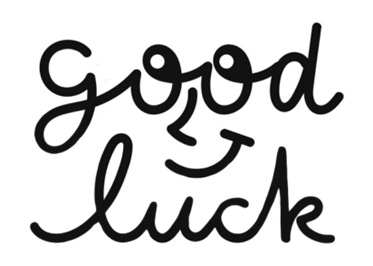